In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
print(f"PyTorch: {torch.__version__}")

PyTorch: 2.10.0+cu128


In [ ]:
!pip install opendatasets -q
import opendatasets as od
od.download("https://www.kaggle.com/datasets/puneet6060/intel-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ap252143@gmail.com
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


100%|██████████| 346M/346M [00:01<00:00, 229MB/s]


In [ ]:
data_dir = 'intel-image-classification'
train_dir = os.path.join(data_dir, 'seg_train', 'seg_train')
test_dir = os.path.join(data_dir, 'seg_test', 'seg_test')

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [ ]:
# Transforms
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset= datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Train dataset samples: {len(train_dataset)}")
print(f"Test dataset samples: {len(test_dataset)}")

Train dataset samples: 14034
Test dataset samples: 3000


Depth matters,  but naive stacking fails.  we can use skip connections, multi-scale, efficient scaling

## VGG - Simplicity and Depth

In [ ]:
from torch.nn.modules import padding
class VGGBlock(nn.Module):
  def __init__(self, in_channels, out_channels, num_covs):
    super().__init__()
    layers = []
    for i in range(num_covs):
      layers.append(nn.Conv2d(
          in_channels if i == 0 else out_channels,
          out_channels, kernel_size=3, padding=1
      ))
      layers.append(nn.BatchNorm2d(out_channels))
      layers.append(nn.ReLU(inplace=True))
    layers.append(nn.MaxPool2d(2, 2))
    self.block = nn.Sequential(*layers)

  def forward(self, x):
    return self.block(x)

#Test
vgg_block = VGGBlock(3, 64, 2)
x = torch.randn(1, 3, 224, 224)
print(f"Input shape: {x.shape}")
print(f"Output shape: {vgg_block(x).shape}")

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 64, 112, 112])


## ResNet - Skipping Connections

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels)
      )
  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    out += self.shortcut(x)  #skip connection
    out = F.relu(out)
    return out

#Test
res_block = ResidualBlock(64, 128, stride=2)
x = torch.randn(1, 64, 56, 56)
print(f"Input shape: {x.shape}")
print(f"Output shape: {res_block(x).shape}")


Input shape: torch.Size([1, 64, 56, 56])
Output shape: torch.Size([1, 128, 28, 28])


## Inception - Multi-scale features

In [ ]:
class InceptionModule(nn.Module):
  def __init__(self, in_channels, ch1x1,  ch3x3_reduce, ch3x3, ch5x5_reduce, ch5x5, pool_proj):
    super().__init__()

    #Branch 1
    self.branch1 = nn.Sequential(
        nn.Conv2d(in_channels, ch1x1, 1),
        nn.BatchNorm2d(ch1x1),
        nn.ReLU(inplace=True)
    )

    #Branch 2
    self.branch2 = nn.Sequential(
        nn.Conv2d(in_channels, ch3x3_reduce, 1),
        nn.BatchNorm2d(ch3x3_reduce),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch3x3_reduce, ch3x3, kernel_size=3, padding=1),
        nn.BatchNorm2d(ch3x3),
        nn.ReLU(inplace=True)
    )

    #Branch 3
    self.branch3 = nn.Sequential(
        nn.Conv2d(in_channels, ch5x5_reduce, 1),
        nn.BatchNorm2d(ch5x5_reduce),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch5x5_reduce, ch5x5, kernel_size=5, padding=2),
        nn.BatchNorm2d(ch5x5),
        nn.ReLU(inplace=True)
    )

    #Branch 4
    self.branch4 = nn.Sequential(
        nn.MaxPool2d(3, stride=1, padding=1),
        nn.Conv2d(in_channels, pool_proj, 1),
        nn.BatchNorm2d(pool_proj),
        nn.ReLU(inplace=True)
    )
  def forward(self, x):
    b1 = self.branch1(x)
    b2 = self.branch2(x)
    b3 = self.branch3(x)
    b4 = self.branch4(x)
    return torch.cat([b1, b2, b3, b4], dim=1)

#Test
inception = InceptionModule(192, 64, 96, 128, 16, 32, 32)
x = torch.randn(1, 192, 28, 28)
out = inception(x)
print(f"Inception Module: {x.shape} → {out.shape}")
print(f"Output channels: 64 + 128 + 32 + 32 = {64+128+32+32}")

Inception Module: torch.Size([1, 192, 28, 28]) → torch.Size([1, 256, 28, 28])
Output channels: 64 + 128 + 32 + 32 = 256


## Densenet - Feature reuse (connect every layer to every other layer)

In [ ]:
class DenseLayer(nn.Module):
  def __init__(self, in_channels, growth_rate):
    super().__init__()
    self.layer = nn.Sequential(
        nn.BatchNorm2d(in_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels, 4 * growth_rate, 1, bias=False),
        nn.BatchNorm2d(4 * growth_rate),
        nn.ReLU(inplace=True),
        nn.Conv2d(4 * growth_rate, growth_rate, 3, padding=1, bias=False)
    )
  def forward(self, x):
    out = self.layer(x)
    return torch.cat([x, out], dim=1)  #concatenation

class DenseBlock(nn.Module):
  def __init__(self, in_channels, growth_rate, num_layers):
    super().__init__()
    layers = []
    current_num_channels = in_channels # Initialize with the block's input channels
    for i in range(num_layers):
      layers.append(DenseLayer(current_num_channels, growth_rate))
      current_num_channels += growth_rate # Update for the next layer due to concatenation
    self.block = nn.Sequential(*layers)
  def forward(self, x):
    return self.block(x)

#Test
dense_block = DenseBlock(64, growth_rate=32, num_layers=4)
x = torch.randn(1, 64, 56, 56)
out = dense_block(x)
print(f"Dense Block: {x.shape} → {out.shape}")
print(f"Output channels: 64 + 4x32 = {64 + 4*32}")

Dense Block: torch.Size([1, 64, 56, 56]) → torch.Size([1, 192, 56, 56])
Output channels: 64 + 4x32 = 192


In [ ]:
# Function to create model with custom head
def create_model(model_name, num_classes, pretrained=True):
    if model_name == 'vgg16':
        model = models.vgg16(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier[-1] = nn.Linear(4096, num_classes)

    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == 'densenet121':
        model = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    return model

print("Models ready")

Models ready


In [ ]:
def train_and_evaluate(model, train_loader, test_loader, epochs=5, lr=0.001):
  model = model.to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  for epoch in range(epochs):
    model.train()
    train_loss, correct, total= 0, 0, 0

    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      train_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

    print(f"Epoch {epoch+1}/{epochs} | Loss {train_loss/len(train_loader):.4f} | Accuracy {100*correct/total:.2f}%")

  model.eval()
  correct, total = 0, 0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)
  test_acc = correct / total
  return test_acc


In [ ]:
# Compare models
model_names = ['mobilenet_v2', 'resnet50', 'densenet121', 'efficientnet_b0']
results = {}

for name in model_names:
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    model = create_model(name, num_classes, pretrained=True)

    # Freeze base, train head only
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze classifier
    if hasattr(model, 'fc'):
        for param in model.fc.parameters():
            param.requires_grad = True
    elif hasattr(model, 'classifier'):
        for param in model.classifier.parameters():
            param.requires_grad = True

    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {params:,} | Trainable: {trainable:,}")

    acc = train_and_evaluate(model, train_loader, test_loader, epochs=3)

    results[name] = {
        'accuracy': acc,
        'params': params
    }

    print(f"\n{name} → Test Accuracy: {acc:.2%}")


Training mobilenet_v2...
Total params: 2,231,558 | Trainable: 7,686
Epoch 1/3 | Loss 0.5013 | Accuracy 82.84%
Epoch 2/3 | Loss 0.3626 | Accuracy 86.93%
Epoch 3/3 | Loss 0.3543 | Accuracy 87.24%

mobilenet_v2 → Test Accuracy: 87.67%

Training resnet50...
Total params: 23,520,326 | Trainable: 12,294
Epoch 1/3 | Loss 0.4883 | Accuracy 83.05%
Epoch 2/3 | Loss 0.3397 | Accuracy 87.64%
Epoch 3/3 | Loss 0.3219 | Accuracy 88.01%

resnet50 → Test Accuracy: 88.83%

Training densenet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 150MB/s]


Total params: 6,960,006 | Trainable: 6,150
Epoch 1/3 | Loss 0.5672 | Accuracy 81.74%
Epoch 2/3 | Loss 0.3493 | Accuracy 88.00%
Epoch 3/3 | Loss 0.3268 | Accuracy 88.25%

densenet121 → Test Accuracy: 89.33%

Training efficientnet_b0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.6MB/s]


Total params: 4,015,234 | Trainable: 7,686
Epoch 1/3 | Loss 0.5880 | Accuracy 81.57%
Epoch 2/3 | Loss 0.4032 | Accuracy 86.14%
Epoch 3/3 | Loss 0.3690 | Accuracy 87.05%

efficientnet_b0 → Test Accuracy: 87.63%


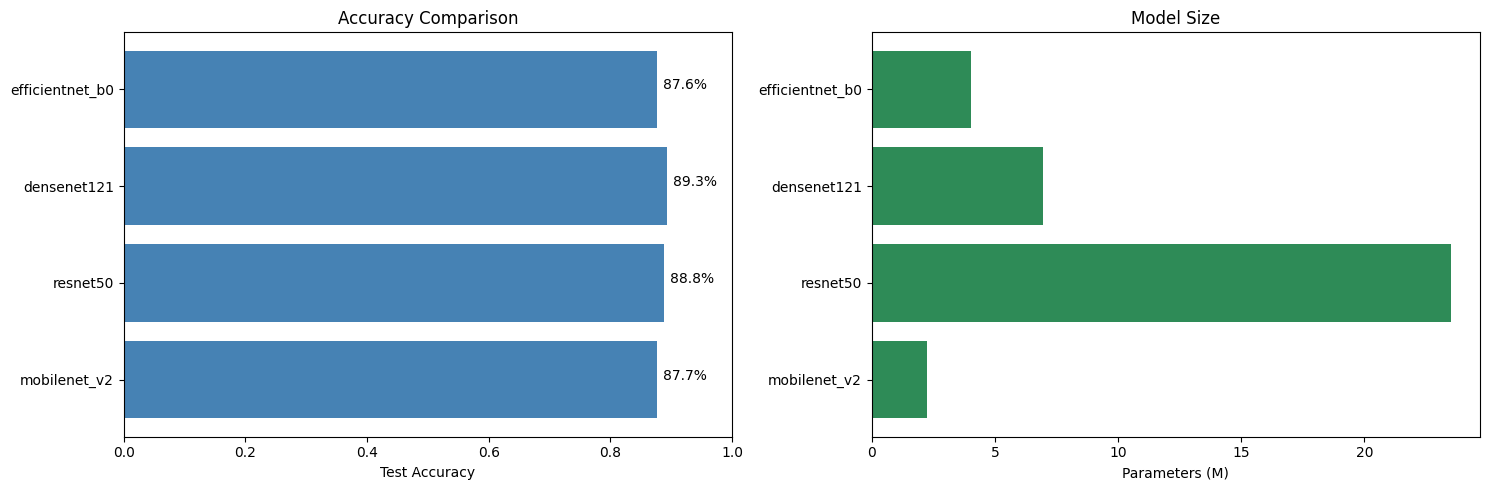

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
params = [results[n]['params'] / 1e6 for n in names]

# Accuracy
axes[0].barh(names, accs, color='steelblue')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlim(0, 1)
for i, v in enumerate(accs):
    axes[0].text(v + 0.01, i, f'{v:.1%}')

# Parameters
axes[1].barh(names, params, color='seagreen')
axes[1].set_xlabel('Parameters (M)')
axes[1].set_title('Model Size')

plt.tight_layout()
plt.show()

## Summary


| Architecture | Key Innovation | Use Case |
|--------------|----------------|----------|
| VGG | Stack 3x3 | Simple baseline |
| ResNet | Skip connections | General purpose |
| Inception | Multi-scale | Feature variety |
| DenseNet | Dense connections | Small datasets |
| EfficientNet | Compound scaling | Efficiency |

### Key Takeaways

1. Skip connections enable very deep networks
2. 1x1 convs reduce computation (bottleneck)
3. Pretrained models beat training from scratch
4. EfficientNet gives best accuracy/compute tradeoff
